# Support Vector Machine: el problema de optimización de los pesos

En este cuaderno se plantea el problema de optimización que resuelve un SVM para encontrar los mejores pesos $w$ y el sesgo $b$, se muestra por qué es un problema de optimización convexa y se resuelve numéricamente con `cvxpy` sobre un conjunto de datos de ejemplo.

Se parte de un conjunto de datos $\{(x_i, y_i)\}_{i=1}^{m}$ con etiquetas $y_i \in \{-1, +1\}$. Se busca un hiperplano

$$w \cdot x + b = 0$$

que separe las dos clases dejando el mayor margen posible entre ellas.

## El margen

La distancia con signo de un punto $x_i$ al hiperplano es $\dfrac{w\cdot x_i + b}{\lVert w\rVert}$. Como la etiqueta $y_i$ vale $+1$ o $-1$, la cantidad

$$y_i\,(w\cdot x_i + b)$$

es positiva cuando el punto está bien clasificado, y su valor mide qué tan lejos queda del hiperplano (esto se llama margen funcional).

Los pesos $w$ y $b$ se pueden reescalar sin cambiar el hiperplano, así que se fija la escala pidiendo que los puntos más cercanos cumplan $y_i(w\cdot x_i+b)=1$. Con esa normalización, la distancia de esos puntos al hiperplano (el margen geométrico) queda

$$\frac{1}{\lVert w\rVert}.$$

Entonces maximizar el margen es lo mismo que minimizar $\lVert w\rVert$.

## El problema de optimización (margen duro)

Maximizar $1/\lVert w\rVert$ equivale a minimizar $\tfrac{1}{2}\lVert w\rVert^2$ (se usa el cuadrado y el $\tfrac12$ solo por comodidad al derivar). Con la condición de que todos los puntos queden bien clasificados y fuera del margen, el problema queda

$$
\begin{aligned}
\min_{w,\,b}\quad & \tfrac{1}{2}\lVert w\rVert^2 \\
\text{s.a.}\quad & y_i\,(w\cdot x_i + b) \ge 1, \qquad i=1,\dots,m.
\end{aligned}
$$

Estos son los "mejores pesos" que pide el enunciado: los que dan el hiperplano de máximo margen.

## Por qué es convexo

- La función objetivo $\tfrac12\lVert w\rVert^2 = \tfrac12 w^\top w$ es una cuadrática con matriz identidad, que es semidefinida positiva, así que es convexa.
- Cada restricción $y_i(w\cdot x_i + b) \ge 1$ es lineal (afín) en $w$ y $b$, así que define un semiespacio, que es convexo. La intersección de semiespacios sigue siendo convexa.

Como se minimiza una función convexa sobre un conjunto convexo, el problema es convexo. De hecho es un programa cuadrático (QP), y al ser convexo cualquier mínimo local es global, por lo que la solución que entregue el solver es la óptima.

## Formulación dual

Introduciendo multiplicadores de Lagrange $\alpha_i \ge 0$ para cada restricción, la lagrangiana es

$$L(w,b,\alpha) = \tfrac12\lVert w\rVert^2 - \sum_{i=1}^m \alpha_i\big[y_i(w\cdot x_i + b) - 1\big].$$

Anulando las derivadas respecto de $w$ y $b$ se obtiene

$$w = \sum_{i=1}^m \alpha_i y_i x_i, \qquad \sum_{i=1}^m \alpha_i y_i = 0.$$

Sustituyendo, el problema dual queda

$$
\begin{aligned}
\max_{\alpha}\quad & \sum_{i=1}^m \alpha_i - \tfrac12 \sum_{i=1}^m\sum_{j=1}^m \alpha_i\alpha_j y_i y_j\,(x_i\cdot x_j) \\
\text{s.a.}\quad & \alpha_i \ge 0, \qquad \sum_{i=1}^m \alpha_i y_i = 0.
\end{aligned}
$$

Por las condiciones KKT, solo los puntos con $\alpha_i > 0$ influyen en $w$: esos son los vectores de soporte. La expresión $w = \sum \alpha_i y_i x_i$ muestra que los pesos son una combinación de unos pocos puntos, los que quedan sobre el margen.

## Resolución numérica con optimización convexa

Se genera un conjunto de datos separable en 2D y se resuelve el problema primal con `cvxpy`.

In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

np.random.seed(0)
X, y = make_blobs(n_samples=40, centers=2, random_state=6, cluster_std=1.1)
y = np.where(y == 0, -1, 1)      # etiquetas en {-1, +1}
m, d = X.shape
print("datos:", X.shape, " etiquetas:", np.unique(y))

datos: (40, 2)  etiquetas: [-1  1]


In [2]:
# Primal:  min 1/2||w||^2  s.a.  y_i (w.x_i + b) >= 1
w = cp.Variable(d)
b = cp.Variable()

objetivo = cp.Minimize(0.5 * cp.sum_squares(w))
restricciones = [cp.multiply(y, X @ w + b) >= 1]

problema = cp.Problem(objetivo, restricciones)
problema.solve()

w_val, b_val = w.value, b.value
print("estado:", problema.status)
print("w =", w_val)
print("b =", b_val)
print("margen = 1/||w|| =", 1 / np.linalg.norm(w_val))

estado: optimal
w = [-0.30248099 -0.9997648 ]
b = -3.8077973511342695
margen = 1/||w|| = 0.9573765129477712


Los vectores de soporte son los puntos que quedan justo sobre el margen, es decir donde $y_i(w\cdot x_i + b) = 1$.

In [3]:
margen_funcional = y * (X @ w_val + b_val)
sv = margen_funcional < 1 + 1e-4          # puntos sobre el margen
print("número de vectores de soporte:", sv.sum())

número de vectores de soporte: 3


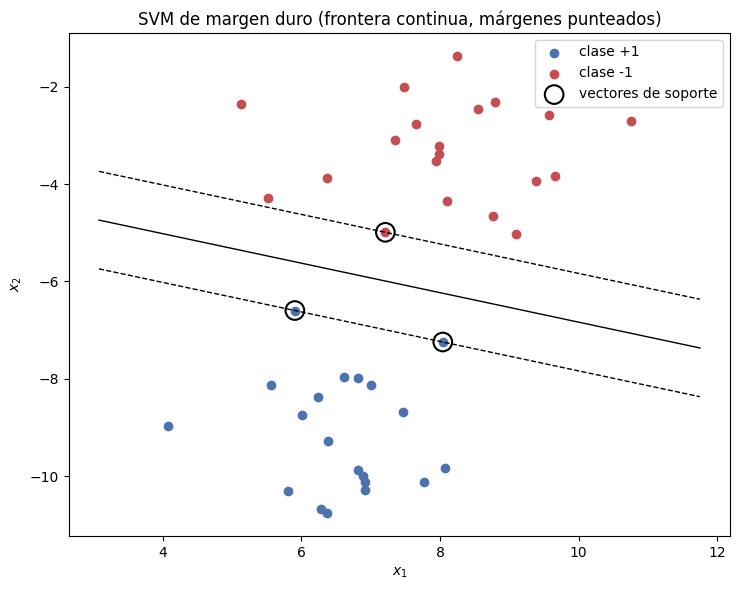

In [4]:
def graficar_svm(X, y, w, b, sv, titulo):
    fig, ax = plt.subplots(figsize=(7.5, 6))
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="#4C72B0", label="clase +1")
    ax.scatter(X[y == -1, 0], X[y == -1, 1], c="#C44E52", label="clase -1")
    ax.scatter(X[sv, 0], X[sv, 1], s=180, facecolors="none",
               edgecolors="k", linewidths=1.5, label="vectores de soporte")

    xx = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
    for nivel, estilo in [(0, "-"), (1, "--"), (-1, "--")]:
        yy = -(w[0] * xx + b - nivel) / w[1]
        ax.plot(xx, yy, "k", ls=estilo, lw=1)

    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.set_title(titulo); ax.legend(loc="best")
    plt.tight_layout(); plt.show()

graficar_svm(X, y, w_val, b_val, sv,
             "SVM de margen duro (frontera continua, márgenes punteados)")

La recta continua es el hiperplano separador y las punteadas marcan el margen. Los puntos rodeados son los vectores de soporte: son los únicos que determinan la solución.

### Resolución por el dual

Se resuelve ahora el problema dual y se comprueba que se obtiene el mismo $w$. Se arma la matriz $Q_{ij} = y_i y_j\, (x_i\cdot x_j)$.

In [5]:
Q = (y[:, None] * X) @ (y[:, None] * X).T     # Q_ij = y_i y_j x_i.x_j

alpha = cp.Variable(m)
dual = cp.Problem(
    cp.Maximize(cp.sum(alpha) - 0.5 * cp.quad_form(alpha, cp.psd_wrap(Q))),
    [alpha >= 0, y @ alpha == 0]
)
dual.solve()
a_val = alpha.value

# recuperar w y b a partir de los multiplicadores
w_dual = ((a_val * y)[:, None] * X).sum(axis=0)
sv_dual = a_val > 1e-4
b_dual = np.mean(y[sv_dual] - X[sv_dual] @ w_dual)

print("estado dual:", dual.status)
print("w (dual)  =", w_dual)
print("w (primal)=", w_val)
print("vectores de soporte (alpha>0):", sv_dual.sum())

estado dual: optimal
w (dual)  = [-0.30248099 -0.9997648 ]
w (primal)= [-0.30248099 -0.9997648 ]
vectores de soporte (alpha>0): 3


El $w$ recuperado del dual coincide con el del primal, como debe ser: al ser un problema convexo con restricciones afines no hay brecha de dualidad. Además los vectores de soporte que salen del dual (los $\alpha_i>0$) son los mismos puntos sobre el margen.

## Caso no separable: margen blando

Cuando los datos no se pueden separar con una recta, no existe $w$ que cumpla todas las restricciones. Se agregan variables de holgura $\xi_i \ge 0$ que permiten violar el margen, penalizadas por una constante $C > 0$:

$$
\begin{aligned}
\min_{w,\,b,\,\xi}\quad & \tfrac12\lVert w\rVert^2 + C\sum_{i=1}^m \xi_i \\
\text{s.a.}\quad & y_i(w\cdot x_i + b) \ge 1 - \xi_i, \quad \xi_i \ge 0.
\end{aligned}
$$

Sigue siendo convexo (se suma un término lineal en $\xi$ y restricciones afines). El parámetro $C$ controla el equilibrio entre margen ancho y errores permitidos.

estado: optimal  errores dentro del margen: 9


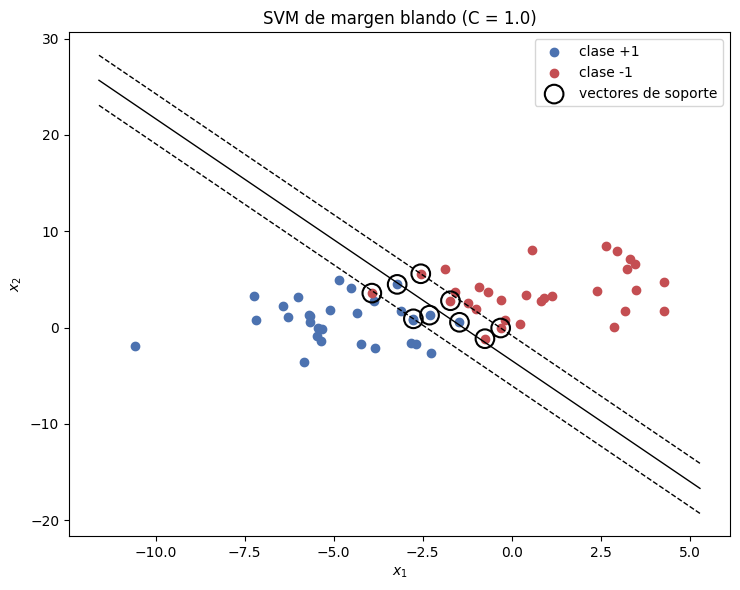

In [6]:
# datos con solape entre clases
Xs, ys = make_blobs(n_samples=60, centers=2, random_state=3, cluster_std=2.2)
ys = np.where(ys == 0, -1, 1)
ms = Xs.shape[0]

C = 1.0
w2 = cp.Variable(d); b2 = cp.Variable(); xi = cp.Variable(ms)
blando = cp.Problem(
    cp.Minimize(0.5 * cp.sum_squares(w2) + C * cp.sum(xi)),
    [cp.multiply(ys, Xs @ w2 + b2) >= 1 - xi, xi >= 0]
)
blando.solve()
w2_val, b2_val = w2.value, b2.value

sv2 = (ys * (Xs @ w2_val + b2_val)) < 1 + 1e-4
print("estado:", blando.status, " errores dentro del margen:", sv2.sum())
graficar_svm(Xs, ys, w2_val, b2_val, sv2,
             f"SVM de margen blando (C = {C})")

Con margen blando algunos puntos quedan dentro del margen o del lado equivocado, pero el problema sigue teniendo solución y sigue siendo convexo.

## Verificación con `scikit-learn`

Para comprobar que el planteamiento es correcto, se compara con la implementación de `SVC`. Usando un $C$ muy grande, `SVC` reproduce el caso de margen duro.

In [7]:
from sklearn.svm import SVC

clf = SVC(kernel="linear", C=1e6).fit(X, y)
print("w (cvxpy)   =", w_val)
print("w (sklearn) =", clf.coef_[0])
print("b (cvxpy)   =", b_val)
print("b (sklearn) =", clf.intercept_[0])

w (cvxpy)   = [-0.30248099 -0.9997648 ]
w (sklearn) = [-0.30271862 -0.99957041]
b (cvxpy)   = -3.8077973511342695
b (sklearn) = -3.8049007385028193


Los pesos coinciden salvo pequeñas diferencias numéricas, lo que confirma que el problema convexo planteado a mano y resuelto con `cvxpy` es el mismo que resuelve un SVM estándar.

## Conclusión

El SVM busca los pesos $w$ y el sesgo $b$ que maximizan el margen entre las clases. Ese objetivo se escribe como el problema convexo

$$\min_{w,b}\ \tfrac12\lVert w\rVert^2 \quad\text{s.a.}\quad y_i(w\cdot x_i+b)\ge 1,$$

que es un programa cuadrático con restricciones afines. Al ser convexo, tiene un único óptimo global que se puede hallar con un solver de optimización convexa. La formulación dual muestra que la solución depende solo de unos pocos puntos (los vectores de soporte), y agregando holguras $\xi_i$ el mismo esquema se extiende a datos no separables sin perder la convexidad.